In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_digits
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import validation_curve
from deslib.des.knora_e import KNORAE


from sklearn.metrics import (
    accuracy_score, mean_squared_error, root_mean_squared_error, 
    f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, 
    mean_absolute_error, r2_score
)


## Stacking Models using DESLIB

# # Train a pool of 10 classifiers
# pool_classifiers = RandomForestClassifier(n_estimators=10)
# pool_classifiers.fit(X_train, y_train)

# # Initialize the DES model
# knorae = KNORAE(pool_classifiers)

# # Preprocess the Dynamic Selection dataset (DSEL)
# knorae.fit(X_dsel, y_dsel)

# # Predict new examples:
# knorae.predict(X_test)


In [41]:
df = pd.read_csv(r"/home/noneo/Codes/ML/MachineLearning/Datasets/advertising-withmissingdata.csv")
df.head(5)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,NaN,45.1,10.4
2,NaN,45.9,69.3,9.3
3,151.5,41.3,NaN,18.5
4,180.8,10.8,58.4,12.9


In [42]:
X = df.drop('sales', axis=1)
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [43]:
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1
)

In [44]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
y_pred = model.predict(X_test)
y_pred

array([16.731323 , 20.954414 , 21.75896  ,  7.8388553, 23.111729 ,
       13.331456 , 22.551876 ,  9.159469 , 11.703621 , 15.327935 ,
        9.955158 ,  9.224792 , 12.982055 ,  6.020682 , 10.137189 ,
       12.062245 ,  5.734437 , 16.239798 , 11.843745 , 18.830618 ,
       20.236902 , 12.364635 ,  9.956621 , 17.427492 , 10.423589 ,
       11.161676 , 22.670729 , 12.633105 ,  9.881098 ,  7.8329234,
       11.466577 , 10.751712 , 21.112024 ,  6.7409377, 16.738993 ,
       20.408163 , 13.091637 , 22.381254 , 12.026836 ,  6.8107357],
      dtype=float32)

In [46]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.9084
MSE  : 1.6828
RMSE : 1.2972
R²   : 0.9467


In [47]:
train_pred = model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 0.9999051999959092
Test R² : 0.9466855118942953


# **MNIST DATASET**

In [66]:
X, y = fetch_openml('mnist_784', version=1,
                    return_X_y=True, as_frame=False,
                    parser='pandas'
)

y = y.astype(int)


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=10000,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=5000,
    random_state=42,
    stratify=y_train
)


In [68]:
mdoel = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    device="cuda",
    predictor="gpu_predictor",
    eval_metric="mlogloss",
    early_stopping_rounds=20,
    random_state=42
)

In [69]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-mlogloss:2.18731
[1]	validation_0-mlogloss:2.08564
[2]	validation_0-mlogloss:1.99627
[3]	validation_0-mlogloss:1.91463
[4]	validation_0-mlogloss:1.83902
[5]	validation_0-mlogloss:1.77057
[6]	validation_0-mlogloss:1.70601
[7]	validation_0-mlogloss:1.64609
[8]	validation_0-mlogloss:1.59046
[9]	validation_0-mlogloss:1.53818
[10]	validation_0-mlogloss:1.48937
[11]	validation_0-mlogloss:1.44281
[12]	validation_0-mlogloss:1.39884
[13]	validation_0-mlogloss:1.35723
[14]	validation_0-mlogloss:1.31754
[15]	validation_0-mlogloss:1.27975
[16]	validation_0-mlogloss:1.24371
[17]	validation_0-mlogloss:1.20933
[18]	validation_0-mlogloss:1.17636
[19]	validation_0-mlogloss:1.14443
[20]	validation_0-mlogloss:1.11440
[21]	validation_0-mlogloss:1.08557
[22]	validation_0-mlogloss:1.05755
[23]	validation_0-mlogloss:1.03068
[24]	validation_0-mlogloss:1.00476
[25]	validation_0-mlogloss:0.97979
[26]	validation_0-mlogloss:0.95576
[27]	validation_0-mlogloss:0.93265
[28]	validation_0-mlogloss:0.9

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=20,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [70]:
y_val_pred = model.predict(X_val)

val_acc = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", val_acc)

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

Validation Accuracy: 0.9824

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       493
           1       0.99      0.99      0.99       563
           2       0.97      0.99      0.98       499
           3       0.99      0.97      0.98       510
           4       0.99      0.98      0.98       487
           5       0.98      0.98      0.98       451
           6       0.99      0.98      0.99       491
           7       0.98      0.99      0.98       521
           8       0.98      0.97      0.97       488
           9       0.97      0.98      0.98       497

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000


Confusion Matrix (Validation):
[[488   0   1   0   1   0   1   0   2   0]
 [  0 558   2   0   0   0   1   2   0   0]
 [  0   0 494   1   1   0   0   2   0   1]
 [  0   1   3 4

In [71]:
y_test_pred = model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_acc)

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.9779

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       986
           1       0.99      0.99      0.99      1125
           2       0.98      0.98      0.98       999
           3       0.98      0.97      0.97      1020
           4       0.98      0.97      0.98       975
           5       0.99      0.97      0.98       902
           6       0.98      0.99      0.98       982
           7       0.98      0.98      0.98      1042
           8       0.97      0.98      0.97       975
           9       0.96      0.96      0.96       994

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


Confusion Matrix (Test):
[[ 975    1    0    0    2    0    1    0    5    2]
 [   0 1114    5    2    1    0    0    2    1    0]
 [   2    0  976    4    4    0    1    8    2    2]
 [ 

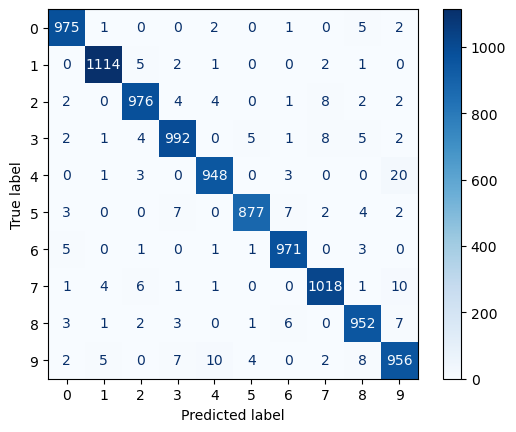

In [72]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [76]:
model.save_model(r"/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Models/mnist_xgboost.json")

In [77]:
import joblib

joblib.dump(model, r"/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Models/mnist_xgboost.pkl")

['/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Models/mnist_xgboost.pkl']